In [1]:
import os
import numpy as np
import math
import pandas as pd
import seaborn as sns
import torch
os.environ["KERAS_BACKEND"] = "torch"
import keras
from keras.callbacks import Callback
from datamodules import data_processors
from sklearn.preprocessing import StandardScaler
import sys
print(sys.version)
from rusmodules import eigenvals, geometry
from rusmodules.inverse import get_constants

(null): No such file or directory
(null): No such file or directory
(null): No such file or directory
(null): No such file or directory


3.14.6 (main, Jun 10 2026, 10:03:53) [GCC 15.2.0]


In [2]:
import matplotlib
matplotlib.rcParams.update({
  #"text.usetex": True,
  "font.family": "serif",
  "font.serif": ["NewComputerModernMath"],
  "mathtext.fontset": "cm",
  "pdf.fonttype": 42,
  "ps.fonttype": 42,
  "font.size": 11,
  "axes.labelsize": "x-large",
  "xtick.labelsize": 13,
  "ytick.labelsize": 13,
  "legend.fontsize": 13,
  "axes.linewidth": 0.8,
  "lines.linewidth": 1.2,
  "lines.markersize": 3.5,
})
import matplotlib.pyplot as plt
%matplotlib inline
#plt.style.use('ggplot')

In [3]:
n_pow = 20
def custom_activation(x):
    return (1/n_pow) * torch.log((1 + torch.exp(n_pow * x)) / (1 + torch.exp(n_pow * (x - 1))))
#fin función

# Wrap the function in a Keras custom layer
@keras.saving.register_keras_serializable()
class CustomActivationLayer(keras.layers.Layer):
    def __init__(self, **kwargs):
        super(CustomActivationLayer, self).__init__(**kwargs)
    
    def call(self, inputs):
        # Ensure inputs are Torch tensors
        inputs = torch.tensor(inputs) if not isinstance(inputs, torch.Tensor) else inputs
        return custom_activation(inputs)
    #fin función
#fin clase
path_to_current_model_cubic = "models/cubico_L4.keras"
modelo_cubico = keras.models.load_model(path_to_current_model_cubic)
path_to_current_model_isotropic = "models/isotropico_act_custom_6.keras"
modelo_isotropico = keras.models.load_model(path_to_current_model_isotropic)
stats_modelo_cubico = pd.read_csv(path_to_current_model_cubic[:-6]+"_stats.csv")
stats_modelo_cubico = stats_modelo_cubico.set_index("Unnamed: 0")
dic_stats = dict(map(lambda x: (x, dict(map(lambda y: (y, stats_modelo_cubico[y][x]),stats_modelo_cubico.keys()))), ["mean", "std"]))
modelo_datos = {"model": modelo_cubico, **dic_stats}

N_data = 200
Ng = 6
shape_def = "Parallelepiped"
N_eig_iso = 5
N_eig_cubic = 20
features_cubic = ["eta", "beta"] + list(map(lambda x: "x_" + str(x), range(N_eig_cubic + 1)))
features_iso = ["eta", "beta"] + list(map(lambda x: "eig_moño_" + str(x+1), range(N_eig_iso)))

In [4]:
geometries = geometry.generate_sphere_surface_points_random(N_data, 0.61*np.pi, np.pi)
geo_df = pd.DataFrame()
geo_df["eta"] = geometries[:,0]
geo_df["beta"] = geometries[:, 1]
print(max(geo_df["eta"])/np.pi)
print(max(geo_df["beta"])/np.pi)

0.6067059791806338
0.9905719721848381


In [5]:
geo_df

,eta,beta
0,0.446092,1.342302
1,0.782944,2.518476
2,0.865215,0.244061
3,0.298919,0.517337
4,1.144007,0.344564
...,...,...
195,1.633900,1.400477
196,1.890055,1.483685
197,0.598672,2.751084
198,1.812278,2.409399


In [6]:
M_max = 250 #GPa
datos_iso = pd.DataFrame()
datos_cubic = pd.DataFrame()
datos_iso["K"] = np.random.uniform(10, M_max, N_data)
datos_iso["G"] = np.random.uniform(10, M_max, N_data)
datos_cubic["K"] = np.random.uniform(10, M_max, N_data)
datos_cubic["mu"] = np.random.uniform(10, M_max, N_data)
datos_cubic["a"] = np.random.uniform(10, M_max, N_data)
datos_cubic["C11"] = datos_cubic["K"] + 2*datos_cubic["a"]
datos_cubic["C12"] = datos_cubic["K"] - datos_cubic["a"]
datos_cubic["C44"] = datos_cubic["mu"]
datos_iso["phi_K"] = np.arctan(datos_iso["G"]/datos_iso["K"])
datos_cubic["phi_K"] = np.arctan(np.sqrt((datos_cubic["a"])**2 + (datos_cubic["mu"])**2)/datos_cubic["K"])
datos_cubic["phi_a"] = np.arctan(datos_cubic["mu"]/datos_cubic["a"])
datos_iso = pd.concat((datos_iso, geo_df), axis = 1)
datos_cubic = pd.concat((datos_cubic, geo_df), axis = 1)

In [7]:
datos_iso

,K,G,phi_K,eta,beta
0,12.045934,153.712178,1.492589,0.446092,1.342302
1,247.966890,33.619488,0.134759,0.782944,2.518476
2,179.680842,225.368322,0.897718,0.865215,0.244061
3,122.064578,177.067219,0.967241,0.298919,0.517337
4,218.570149,98.128280,0.421985,1.144007,0.344564
...,...,...,...,...,...
195,104.744731,230.585293,1.144409,1.633900,1.400477
196,21.877670,87.640113,1.326165,1.890055,1.483685
197,230.127710,107.929908,0.438542,0.598672,2.751084
198,94.394544,43.816347,0.434586,1.812278,2.409399


In [8]:
datos_cubic

,K,mu,a,C11,C12,C44,phi_K,phi_a,eta,beta
0,223.542957,157.859628,167.232933,558.008822,56.310025,157.859628,0.799570,0.756573,0.446092,1.342302
1,182.513356,247.965131,106.963188,396.439731,75.550168,247.965131,0.976465,1.163548,0.782944,2.518476
2,72.056896,23.347137,184.395517,440.847929,-112.338621,23.347137,1.200957,0.125944,0.865215,0.244061
3,196.600011,136.355160,108.128524,412.857058,88.471488,136.355160,0.724561,0.900343,0.298919,0.517337
4,168.748985,48.183001,64.885197,298.519378,103.863788,48.183001,0.446650,0.638741,1.144007,0.344564
...,...,...,...,...,...,...,...,...,...,...
195,111.949309,177.779335,28.533641,169.016592,83.415668,177.779335,1.014536,1.411653,1.633900,1.400477
196,227.082519,75.226687,244.542958,716.168435,-17.460438,75.226687,0.844900,0.298434,1.890055,1.483685
197,128.783747,159.458246,239.837401,608.458550,-111.053654,159.458246,1.150313,0.586751,0.598672,2.751084
198,80.511933,240.170835,16.121206,112.754344,64.390727,240.170835,1.248019,1.503773,1.812278,2.409399


In [9]:
datos_cubic["C11_pred"] = 0.0
datos_cubic["C12_pred"] = 0.0
datos_cubic["C44_pred"] = 0.0

datos_iso["K_pred"] = 0.0
datos_iso["G_pred"] = 0.0
for i in range(N_eig_iso):
  datos_iso[f"eig_{i}"] = 0.0
  datos_iso[f"eig_moño_{i}"] = 0.0

In [10]:
for i in datos_iso.index:
  Ki = datos_iso.at[i, "K"]
  Gi = datos_iso.at[i, "G"]
  eta_g = datos_iso.at[i, "eta"]
  beta_g = datos_iso.at[i, "beta"]
  C_iso = eigenvals.get_elastic_constants({"K": Ki, "mu": Gi})
  eigs_iso = eigenvals.get_eigenvalues(Ng, C_iso, eta_g, beta_g, shape_def)["eig"][:N_eig_iso + 1]
  for j in range(len(eigs_iso)):
    datos_iso.at[i, f"eig_{j}"] = eigs_iso[j]
    if j == 0:
      datos_iso.at[i, f"eig_moño_{j}"] = eigs_iso[j]
    elif j == 1:
      datos_iso.at[i, f"eig_moño_{j}"] = 1/eigs_iso[j]
    else:
      datos_iso.at[i, f"eig_moño_{j}"] = eigs_iso[j-1]/eigs_iso[j]

datos_iso["phi_K_pred"] = modelo_isotropico.predict(datos_iso[features_iso])*(np.pi/2)
  

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


In [11]:
datos_iso[["phi_K", "phi_K_pred", "K", "G", "eig_0"]]

,phi_K,phi_K_pred,K,G,eig_0
0,1.492589,1.497419,12.045934,153.712178,0.327126
1,0.134759,0.183944,247.966890,33.619488,12.688489
2,0.897718,0.923072,179.680842,225.368322,0.184911
3,0.967241,0.952261,122.064578,177.067219,0.016116
4,0.421985,0.475303,218.570149,98.128280,0.882120
...,...,...,...,...,...
195,1.144409,1.212400,104.744731,230.585293,182.524203
196,1.326165,1.266427,21.877670,87.640113,87.168208
197,0.438542,0.446269,230.127710,107.929908,15.876618
198,0.434586,0.505532,94.394544,43.816347,124.394472


In [17]:
for i in datos_iso.index:
  phi_K_p = datos_iso.at[i, "phi_K_pred"]
  eta_g = datos_iso.at[i, "eta"]
  beta_g = datos_iso.at[i, "beta"]
  eig0_ref_l = eigenvals.forward_standard({"phi_K": phi_K_p}, eta_g, beta_g, "Parallelepiped", Ng)["eig"]
  datos_iso.at[i, "eig_ref_0"] = eig0_ref_l[0]
  datos_iso.at[i, "eig_ref_1"] = eig0_ref_l[1]
  datos_iso.at[i, "eig_ref_2"] = eig0_ref_l[2]
  datos_iso.at[i, "eig_ref_3"] = eig0_ref_l[3]
  datos_iso.at[i, "eig_ref_4"] = eig0_ref_l[4]
  datos_iso.at[i, "eig_ref_5"] = eig0_ref_l[5]

datos_iso["M_pred"] = 1/6*(datos_iso["eig_0"]/datos_iso["eig_ref_0"] * ( 1+
                              datos_iso["eig_1"]/datos_iso["eig_ref_1"] +
                              datos_iso["eig_2"]/datos_iso["eig_ref_2"] +
                              datos_iso["eig_3"]/datos_iso["eig_ref_3"] +
                              datos_iso["eig_4"]/datos_iso["eig_ref_4"] +
                              datos_iso["eig_5"]/datos_iso["eig_ref_5"]))
datos_iso["K_pred"] = datos_iso["M_pred"]*np.cos(datos_iso["phi_K_pred"])
datos_iso["G_pred"] = datos_iso["M_pred"]*np.sin(datos_iso["phi_K_pred"])

In [18]:
datos_iso[["K", "K_pred", "G", "G_pred"]]

,K,K_pred,G,G_pred
0,12.045934,11.720199,153.712178,159.439075
1,247.966890,182.345651,33.619488,33.924927
2,179.680842,172.295784,225.368322,227.717665
3,122.064578,125.149385,177.067219,175.845753
4,218.570149,194.108098,98.128280,99.898711
...,...,...,...,...
195,104.744731,91.569876,230.585293,244.464785
196,21.877670,25.081539,87.640113,79.844319
197,230.127710,226.027572,107.929908,108.145569
198,94.394544,80.028725,43.816347,44.296483


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


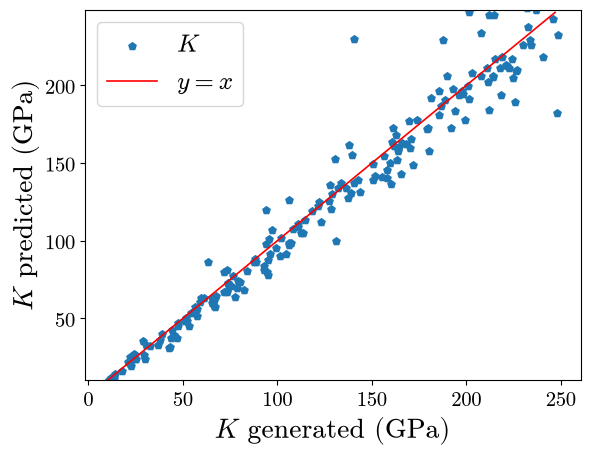

In [22]:
fig_K = plt.figure()
ax1 =fig_K.add_subplot(111)
line_color = "red"
labels_fontsize = 20
ref1 = range(int(min(datos_iso["K"])), int(max(datos_iso["K"])))
ax1.scatter(datos_iso["K"], datos_iso["K_pred"], marker="p", s=30)
ax1.plot(list(ref1), list(ref1), color = line_color)
ax1.set_xlabel(r"$K$ generated (GPa)", fontsize = labels_fontsize)
ax1.set_ylabel(r"$K$ predicted (GPa)", fontsize = labels_fontsize)
ax1.set_ylim(min(datos_iso["K"]), max(datos_iso["K"]))
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.legend([r"$K$", r"$y = x$"], fontsize = 18)
plt.savefig("../Thesis_Docs/pictures/figXX_K.pdf", bbox_inches="tight", pad_inches=0)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


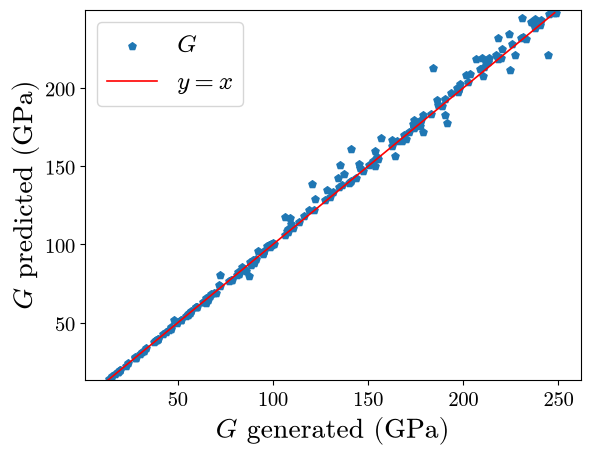

In [21]:
fig_G = plt.figure()
ax1 =fig_G.add_subplot(111)
line_color = "red"
labels_fontsize = 20
ref1 = range(int(min(datos_iso["G"])), int(max(datos_iso["G"])))
ax1.scatter(datos_iso["G"], datos_iso["G_pred"], marker="p", s=30)
ax1.plot(list(ref1), list(ref1), color = line_color)
ax1.set_xlabel(r"$G$ generated (GPa)", fontsize = labels_fontsize)
ax1.set_ylabel(r"$G$ predicted (GPa)", fontsize = labels_fontsize)
ax1.set_ylim(min(datos_iso["G"]), max(datos_iso["G"]))
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.legend([r"$G$", r"$y = x$"], fontsize = 18)
plt.savefig("../Thesis_Docs/pictures/figXX_G.pdf", bbox_inches="tight", pad_inches=0)

In [10]:
for i in datos_cubic.index:
  Ki = datos_cubic.at[i, "K"]
  mui = datos_cubic.at[i, "mu"]
  ai = datos_cubic.at[i, "a"]
  eta_g = datos_cubic.at[i, "eta"]
  beta_g = datos_cubic.at[i, "beta"]
  C_cubic = eigenvals.get_elastic_constants({"K": Ki, "mu": mui, "a": ai})
  eigs_cubic = eigenvals.get_eigenvalues(Ng, C_cubic, eta_g, beta_g, shape_def)["eig"][:N_eig_cubic]
  C_predicted = get_constants(eigs_cubic, eta_g, beta_g, modelo_datos)
  datos_cubic.at[i, "C11_pred"] = C_predicted["C00"]
  datos_cubic.at[i, "C12_pred"] = C_predicted["C01"]
  datos_cubic.at[i, "C44_pred"] = C_predicted["C33"]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━

In [11]:
datos_cubic.dropna()

,K,mu,a,C11,C12,C44,phi_K,phi_a,eta,beta,C11_pred,C12_pred,C44_pred
0,187.897971,56.608453,41.303795,270.505560,146.594176,56.608453,0.356965,0.940453,0.625333,1.353625,206.447426,73.572444,56.843135
1,25.483483,237.106429,64.943128,155.369738,-39.459644,237.106429,1.467506,1.303454,0.590784,1.157650,177.684252,-58.316680,265.057436
2,27.797164,53.726799,164.437101,356.671366,-136.639938,53.726799,1.411473,0.315797,1.236766,0.214524,345.422136,-128.712237,53.082203
3,96.928426,122.230933,43.781288,184.491003,53.147138,122.230933,0.929507,1.226848,1.831393,2.120721,182.927400,53.533052,125.719702
4,110.161351,120.938023,51.786056,213.733462,58.375295,120.938023,0.873691,1.166216,0.526454,2.609076,214.764201,57.421040,118.874157
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,107.669212,135.281361,54.809717,217.288646,52.859494,135.281361,0.935247,1.185855,0.499275,0.973300,203.922864,13.861278,130.962473
196,32.626054,203.138868,51.867574,136.361202,-19.241520,203.138868,1.416417,1.320807,1.732821,0.197403,140.558653,-25.147619,200.688134
197,142.310361,146.687465,222.939910,588.190182,-80.629549,146.687465,1.080898,0.581957,0.395465,0.539813,567.466361,-55.002862,151.757100
198,70.277990,91.686890,238.492112,547.262213,-168.214121,91.686890,1.302383,0.367025,0.786948,0.849531,537.417979,-158.463879,90.024053


In [12]:
datos_graph = datos_cubic.dropna()

In [13]:
print(datos_graph[["C11", "C11_pred", "C12", "C12_pred", "C44", "C44_pred"]])

            C11    C11_pred         C12    C12_pred         C44    C44_pred
0    270.505560  206.447426  146.594176   73.572444   56.608453   56.843135
1    155.369738  177.684252  -39.459644  -58.316680  237.106429  265.057436
2    356.671366  345.422136 -136.639938 -128.712237   53.726799   53.082203
3    184.491003  182.927400   53.147138   53.533052  122.230933  125.719702
4    213.733462  214.764201   58.375295   57.421040  120.938023  118.874157
..          ...         ...         ...         ...         ...         ...
195  217.288646  203.922864   52.859494   13.861278  135.281361  130.962473
196  136.361202  140.558653  -19.241520  -25.147619  203.138868  200.688134
197  588.190182  567.466361  -80.629549  -55.002862  146.687465  151.757100
198  547.262213  537.417979 -168.214121 -158.463879   91.686890   90.024053
199  305.147487  300.122315  -92.150470  -87.691604   21.762539   21.634843

[200 rows x 6 columns]


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


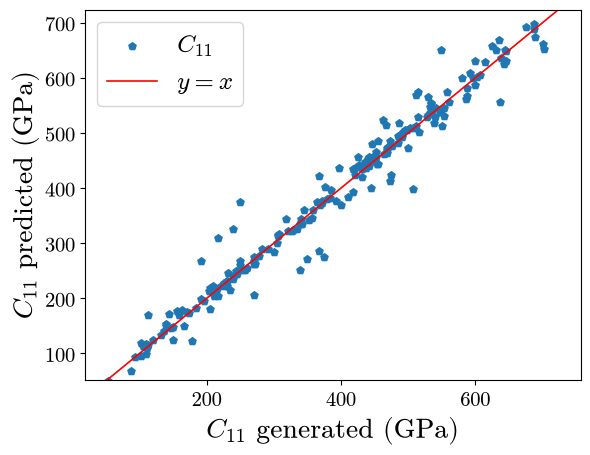

In [14]:
fig_C11 = plt.figure()
ax1 =fig_C11.add_subplot(111)
line_color = "red"
labels_fontsize = 20
ref1 = range(int(min(datos_graph["C11"])), int(max(datos_graph["C11"])))
ax1.scatter(datos_graph["C11"], datos_graph["C11_pred"], marker="p", s=30)
ax1.plot(list(ref1), list(ref1), color = line_color)
ax1.set_xlabel(r"$C_{11}$ generated (GPa)", fontsize = labels_fontsize)
ax1.set_ylabel(r"$C_{11}$ predicted (GPa)", fontsize = labels_fontsize)
ax1.set_ylim(min(datos_graph["C11"]), max(datos_graph["C11"]))
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.legend([r"$C_{11}$", r"$y = x$"], fontsize = 18)
plt.savefig("../Thesis_Docs/pictures/figXX_C11.pdf", bbox_inches="tight", pad_inches=0)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


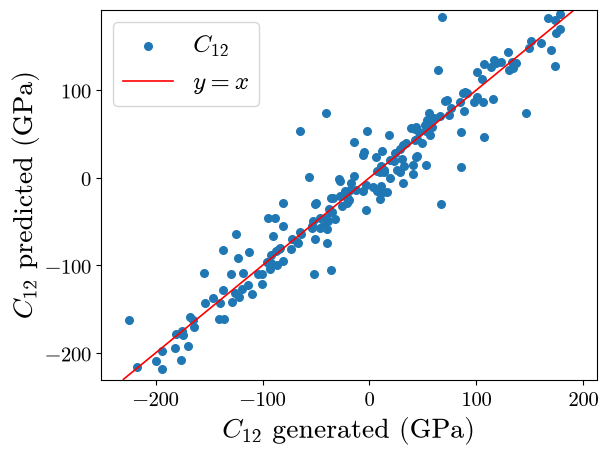

In [15]:
fig_C12 = plt.figure()
ax1 =fig_C12.add_subplot(111)
line_color = "red"
labels_fontsize = 20
ref1 = range(int(min(datos_graph["C12"])), int(max(datos_graph["C12"])))
ax1.scatter(datos_graph["C12"], datos_graph["C12_pred"], marker="o", s=30)
ax1.plot(list(ref1), list(ref1), color = line_color)
ax1.set_xlabel(r"$C_{12}$ generated (GPa)", fontsize = labels_fontsize)
ax1.set_ylabel(r"$C_{12}$ predicted (GPa)", fontsize = labels_fontsize)
ax1.set_ylim(min(datos_graph["C12"]), max(datos_graph["C12"]))
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.legend([r"$C_{12}$", r"$y = x$"], fontsize = 18)
plt.savefig("../Thesis_Docs/pictures/figXX_C12.pdf", bbox_inches="tight", pad_inches=0)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


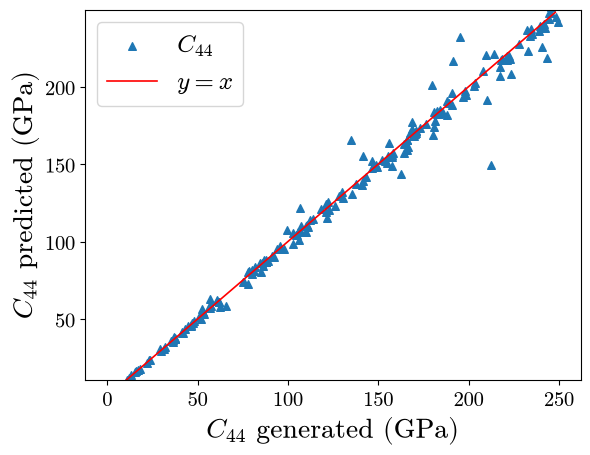

In [16]:
fig_C44 = plt.figure()
ax1 =fig_C44.add_subplot(111)
line_color = "red"
labels_fontsize = 20
ref1 = range(int(max(datos_graph["C44"])))
ax1.scatter(datos_graph["C44"], datos_graph["C44_pred"], marker="^", s=30)
ax1.plot(list(ref1), list(ref1), color = line_color)
ax1.set_xlabel(r"$C_{44}$ generated (GPa)", fontsize = labels_fontsize)
ax1.set_ylabel(r"$C_{44}$ predicted (GPa)", fontsize = labels_fontsize)
ax1.set_ylim(min(datos_graph["C44"]), max(datos_graph["C44"]))
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.legend([r"$C_{44}$", r"$y = x$"], fontsize = 18)
plt.savefig("../Thesis_Docs/pictures/figXX_C44.pdf", bbox_inches="tight", pad_inches=0)